# Housing's price prediction 

## Loading data set

Import the libraries I'm going to use
***
1. Numpy - to deal with math 
2. Pandas - to deal with the data
3. matplotlib.pyplot - to create diagrams
4. to make those diagrams look better😎

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Get the data from the housing.csv using pandas

In [3]:
data = pd.read_csv("Housing.csv")

Here is my data and it's veri veri big

In [4]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## Data Exploration

Reasearch the data (see if there is some data missing) <br>
In my case, all the columns have all the data

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Data Preprocessing

Splitting the data into train one and test <br>
The **train** one will be 80% and the **test** one - 20%

In [6]:
from sklearn.model_selection import train_test_split

X = data.drop(['price'], axis=1)
y = data['price']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Creating a function to process the data easier (cause I have the train and test data).

The function: Joins the X and y into one (ex. "train_data"), replaces yes and no with 1s and 0s, the furnishing is replaced with values: True or False using pd.getdummies(). I also do the np.log for price and area, since they're "right-skewed". And finally returning the final product.

In [8]:
def processing_data(X, y):
    data = X.join(y)
    # Drop one dummy to avoid multicollinearity
    data = data.join(pd.get_dummies(data.furnishingstatus, drop_first=True)).drop(
        ["furnishingstatus"], axis=1)
    '''multicollinearity is when you can predict one thing based on the other two
    ex. If semi-furnished and unfurnished is equal to 0, then furnished must be 1. 
    Dropping the first column (furnished) removes redundancy(identic items) without losing information'''
    data = data.replace({'yes': 1, 'no': 0})
    data['price'] = np.log(data['price'])
    data['area'] = np.log1p(data['area'])
    return data

Here I use the function created above to make the train_data for my models

In [9]:
train_data = processing_data(X_train, y_train)
train_data

C:\Users\User\AppData\Local\Temp\ipykernel_20320\3768248154.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'yes': 1, 'no': 0})


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,price,semi-furnished,unfurnished
41,8.757941,3,2,4,1,0,0,0,1,0,1,15.874749,False,False
414,8.304247,2,1,1,1,0,0,0,0,0,0,15.046028,False,True
499,8.197263,3,3,2,0,1,0,0,0,0,0,14.793837,False,True
521,8.198639,2,1,1,0,0,0,0,0,0,0,14.694307,False,True
169,8.785845,4,2,2,0,0,0,0,1,0,0,15.473739,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,9.346705,3,1,3,1,0,0,0,0,2,1,15.585876,True,False
67,8.949105,3,2,1,1,0,0,0,0,2,0,15.746307,False,True
473,8.993552,2,1,1,1,0,0,0,0,0,0,14.915122,False,True
506,7.976252,2,1,1,0,0,0,0,0,0,0,14.772559,False,True


In [10]:
test_data = processing_data(X_test, y_test)

C:\Users\User\AppData\Local\Temp\ipykernel_20320\3768248154.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'yes': 1, 'no': 0})


The final diagram for my *train_data*, where area and price data has been through the log function

array([[<Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'mainroad'}>,
        <Axes: title={'center': 'guestroom'}>],
       [<Axes: title={'center': 'basement'}>,
        <Axes: title={'center': 'hotwaterheating'}>,
        <Axes: title={'center': 'airconditioning'}>],
       [<Axes: title={'center': 'parking'}>,
        <Axes: title={'center': 'prefarea'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

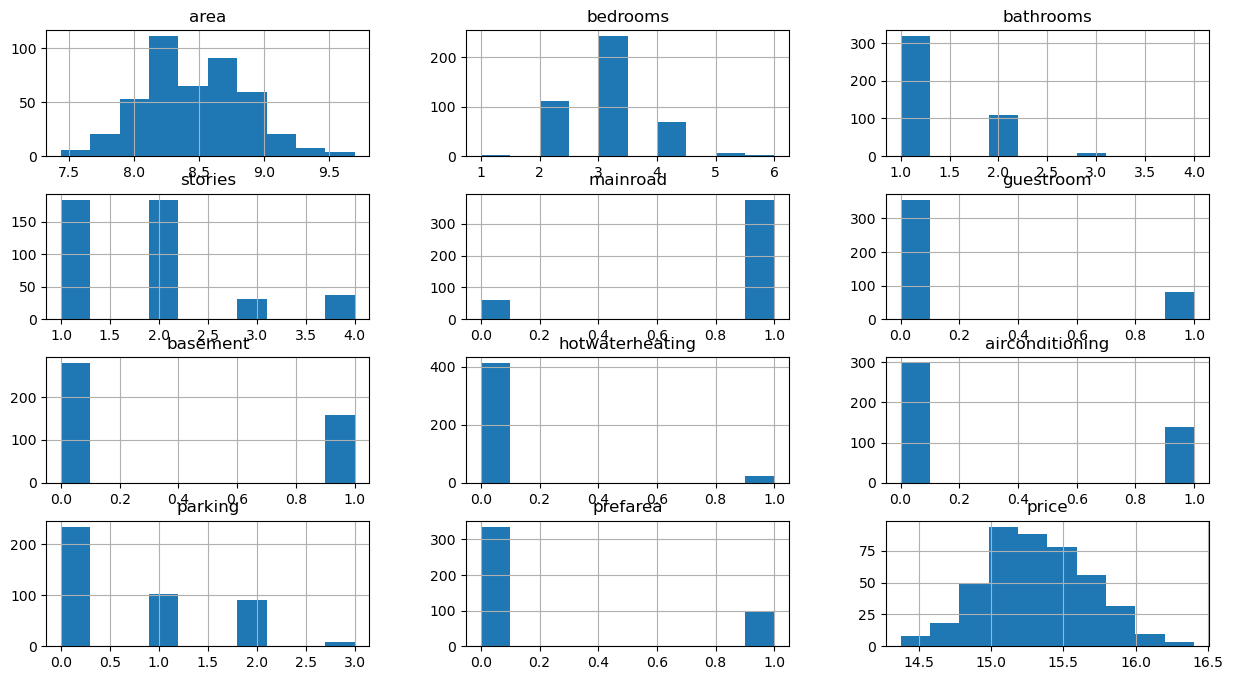

In [11]:
train_data.hist(figsize = (15,8))

Next, we analyze the correlation between the variables.
***
* 1 means a perfect positive correlation: when one variable increases, the other also increases (direct proportionality).
* Values between 0 and 1 indicate a positive correlation as well, but with a weaker influence.
* Negative values indicate a negative correlation: when one variable increases, the other decreases (inverse proportionality).

From the correlation matrix, the variables that have the strongest influence on **price** are *area*, *number of bathrooms* (to some extent), and *air conditioning*.

<Axes: >

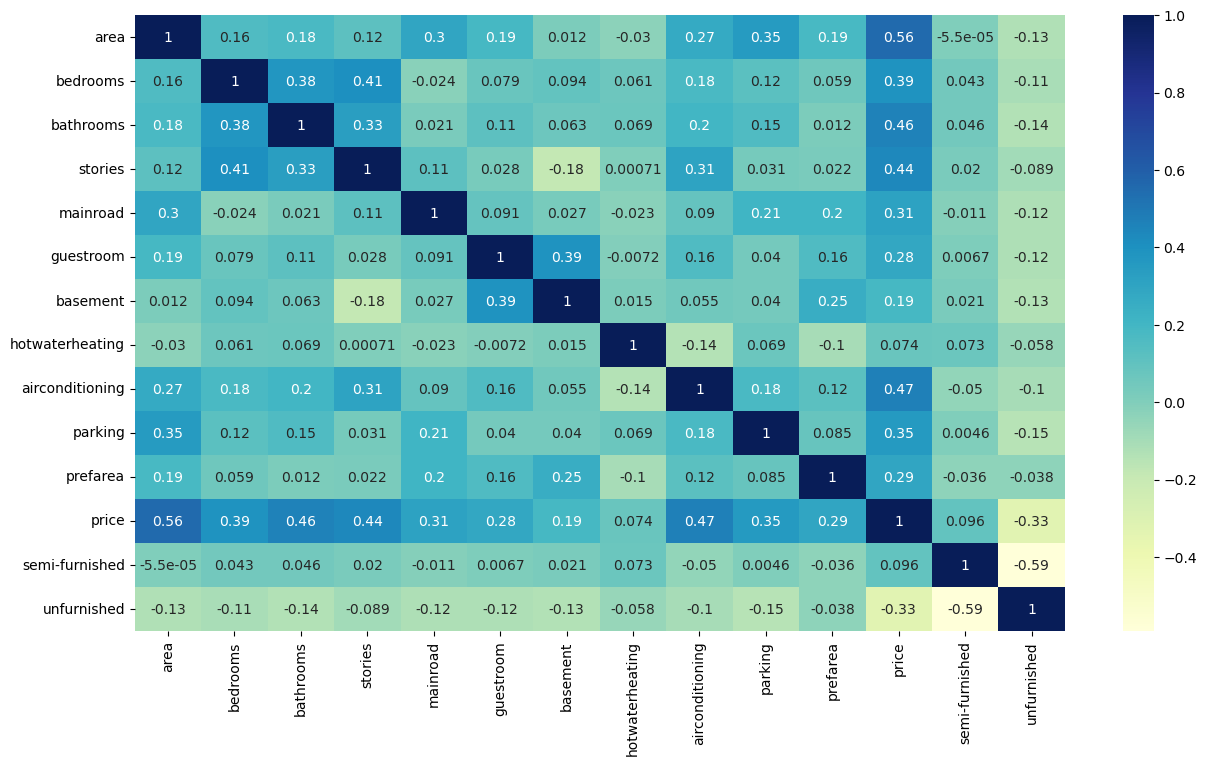

In [12]:
# creates a heatmap to show the correlation between the things
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

Scatterplot between price and area. <br>
After looking at it, you can see that if the area goes up, so does the price and it forms a diagonal line

<Axes: xlabel='area', ylabel='price'>

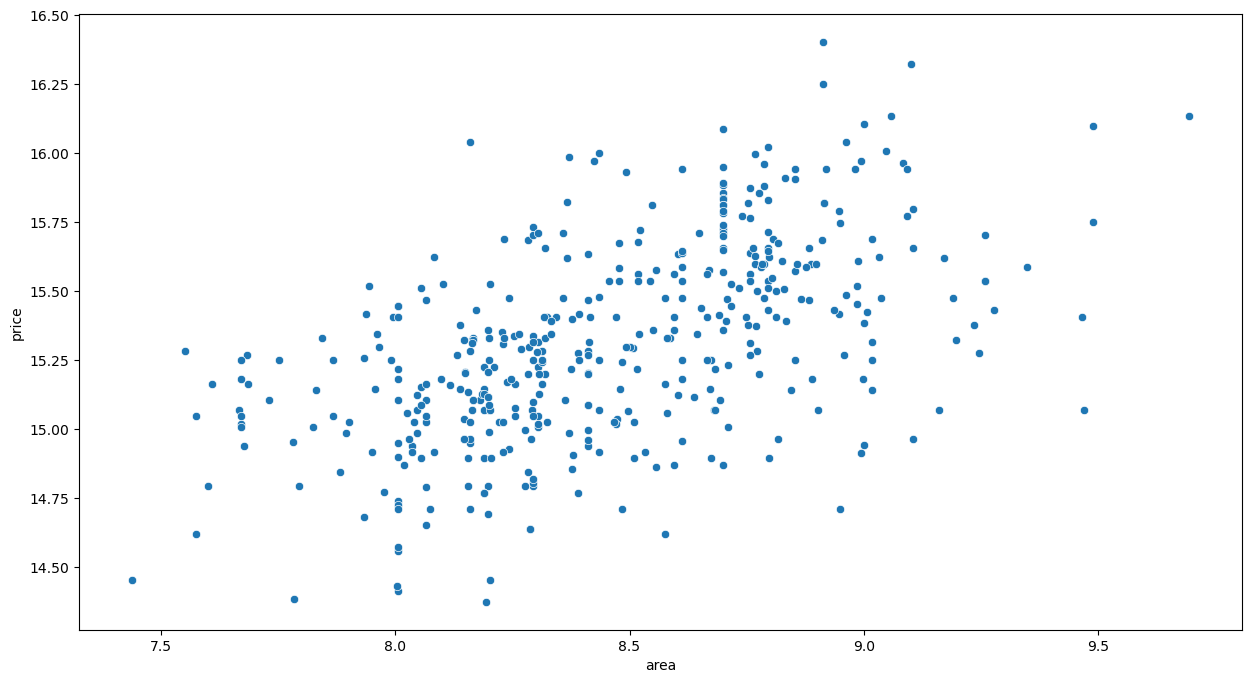

In [13]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='area', y='price', data=train_data)

## Creating the "Linear Regression" model

Dividing the train and test data into 2 parts: <br>
1.  X - has everything from the dataset, except the house price
2.  y - only the price

In [14]:
# The train data
X_train, y_train = train_data.drop(['price'], axis=1), train_data['price']
# The test data
X_test, y_test = test_data.drop(['price'], axis=1), test_data['price']

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

linear_model = LinearRegression()
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # scales the train data

linear_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_train_numeric = X_train.astype(int) # convert into int, because I had float in some columns
vif_data = pd.DataFrame() 
vif_data["Feature"] = X_train_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(
    X_train_numeric.values, i) for i in range(X_train_numeric.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False))

            Feature        VIF
0              area  31.594669
1          bedrooms  22.639644
2         bathrooms   9.729080
4          mainroad   8.379748
3           stories   7.619367
11   semi-furnished   2.709476
12      unfurnished   2.513628
6          basement   2.108404
9           parking   1.914420
8   airconditioning   1.789192
5         guestroom   1.509613
10         prefarea   1.484896
7   hotwaterheating   1.114303


In [17]:
X_test_scaled = scaler.transform(X_test) # scales the test data

In [18]:
final_score = linear_model.score(X_test_scaled, y_test)

print(f"The model's R² score is: {final_score:.2%}%")

The model's R² score is: 75.21%%


In [31]:
# prints the answers not scientifically
pd.options.display.float_format = '{:.0f}'.format

# Predict on test set (log prices)
y_pred_log = linear_model.predict(X_test_scaled)

# Convert back to actual prices using the exponent function from numpy
y_pred_actual = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)
difference = y_test_actual - y_pred_actual

tolerance = 0.05 * y_test_actual
# Display first 10 predictions vs actual
results = pd.DataFrame({
    'Actual Price': y_test_actual,
    'Predicted Price': y_pred_actual,
    'Difference': difference,
    'Status': np.where(abs(difference) <= tolerance, 'almost perfect',
                       np.where(difference > 0, 'too low', 'too high'))
})
print(results.head(10))

     Actual Price  Predicted Price  Difference          Status
213       4893000          4812576       80424  almost perfect
500       2660000          2789651     -129651  almost perfect
15        9100000          5174510     3925490         too low
461       3080000          3977493     -897493        too high
472       3010000          4312907    -1302907        too high
407       3465000          3911620     -446620        too high
434       3290000          3892008     -602008        too high
536       1960000          3160398    -1200398        too high
219       4795000          4270769      524231         too low
117       5950000          4818095     1131905         too low


In [20]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate MAPE (lower is better, e.g., 0.15 = 15% average error)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")

Mean Absolute Percentage Error (MAPE): 16.69%


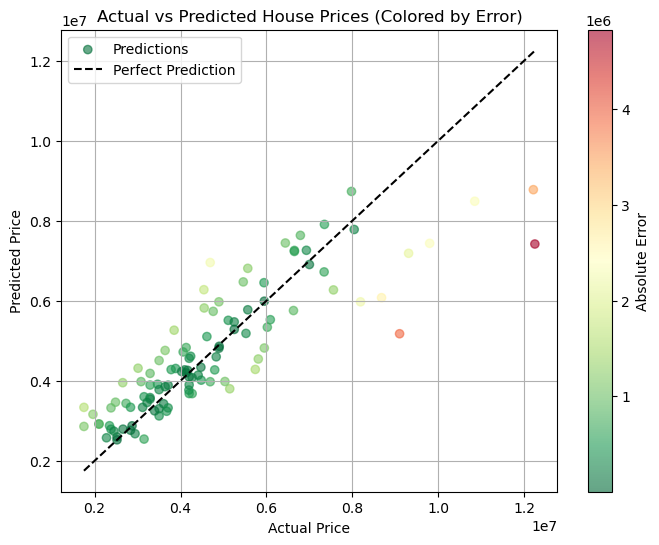

In [21]:
# Calculate absolute difference for coloring
abs_diff = np.abs(y_test_actual - y_pred_actual)

# Scatter plot with color based on difference
plt.figure(figsize=(8, 6))
scatter = plt.scatter(y_test_actual, y_pred_actual, c=abs_diff,
                      cmap='RdYlGn_r', alpha=0.6, label='Predictions')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()],
         color='black', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Colored by Error)')
plt.legend()
plt.grid(True)
plt.colorbar(scatter, label='Absolute Error')
plt.show()

## Creating the "Random Forest" model

In [22]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor()

forest_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
forest_model.score(X_test_scaled, y_test)

0.7394791578730514

In [24]:
from sklearn.model_selection import GridSearchCV

forest_model = RandomForestRegressor()

param_grid = {
    "n_estimators": [10, 30, 50],
    "max_features": [2, 4, 6, 8],
    "min_samples_split": [2, 4, 6, 8]
}

grid_search = GridSearchCV(forest_model, param_grid, cv=5,
                           scoring= "neg_mean_squared_error",
                           return_train_score=True)

grid_search.fit(X_train_scaled, y_train)


,estimator,RandomForestRegressor()
,param_grid,"{'max_features': [2, 4, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [10, 30, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,50


In [25]:
best_forest = grid_search.best_estimator_
grid_search.best_params_

{'max_features': 6, 'min_samples_split': 8, 'n_estimators': 50}

In [26]:
best_forest.score(X_test_scaled, y_test)

0.7308794273089557

## Conclusion

In this project, a model was built to predict housing prices using different house features. The data was processed and analyzed to understand how each feature affects the price. The analysis showed that area has the strongest influence on housing prices, followed by bathrooms and air conditioning.<br>

The model’s predictions were generally close to the real prices, with many results being classified as almost perfect. Some differences still exist, which is normal because the data set given was small.<br>

Overall, the project shows that machine learning can be effectively used to predict housing prices and understand the factors that affect them. The model can be improved in the future by adding more features or using more advanced models.<br>

Besides the **Linear Regression** model, a **Random Forest** model was also tested. However, the results were slightly worse compared to Linear Regression. This is likely because the relationships in the dataset are mostly **linear**, and Linear Regression is better suited for capturing linear patterns. Random Forest models are more effective when the data contains complex, non-linear relationships, which were limited in this case.<br>

### Results:
- The linear regression model explained about 64% of the variance in house prices, which is reasonable given the dataset's complexity and size.
- Predictions included a status indicator ("too low", "too high" or "almost perfect") to show the direction of errors.
- Random forest performed better after tuning, capturing non-linear relationships more effectively, but it still wasn't better than linear regression.

### Insights:
- Area, number of bathrooms, and air conditioning were the strongest influence in the process of predicting the price.
- Log transformations helped handle skewed data for *area* and *price*, improving model performance.
- Dropping dummy variables (the first column - funrished) reduced multicollinearity, leading to more stable coefficients.